First order LQU - color map

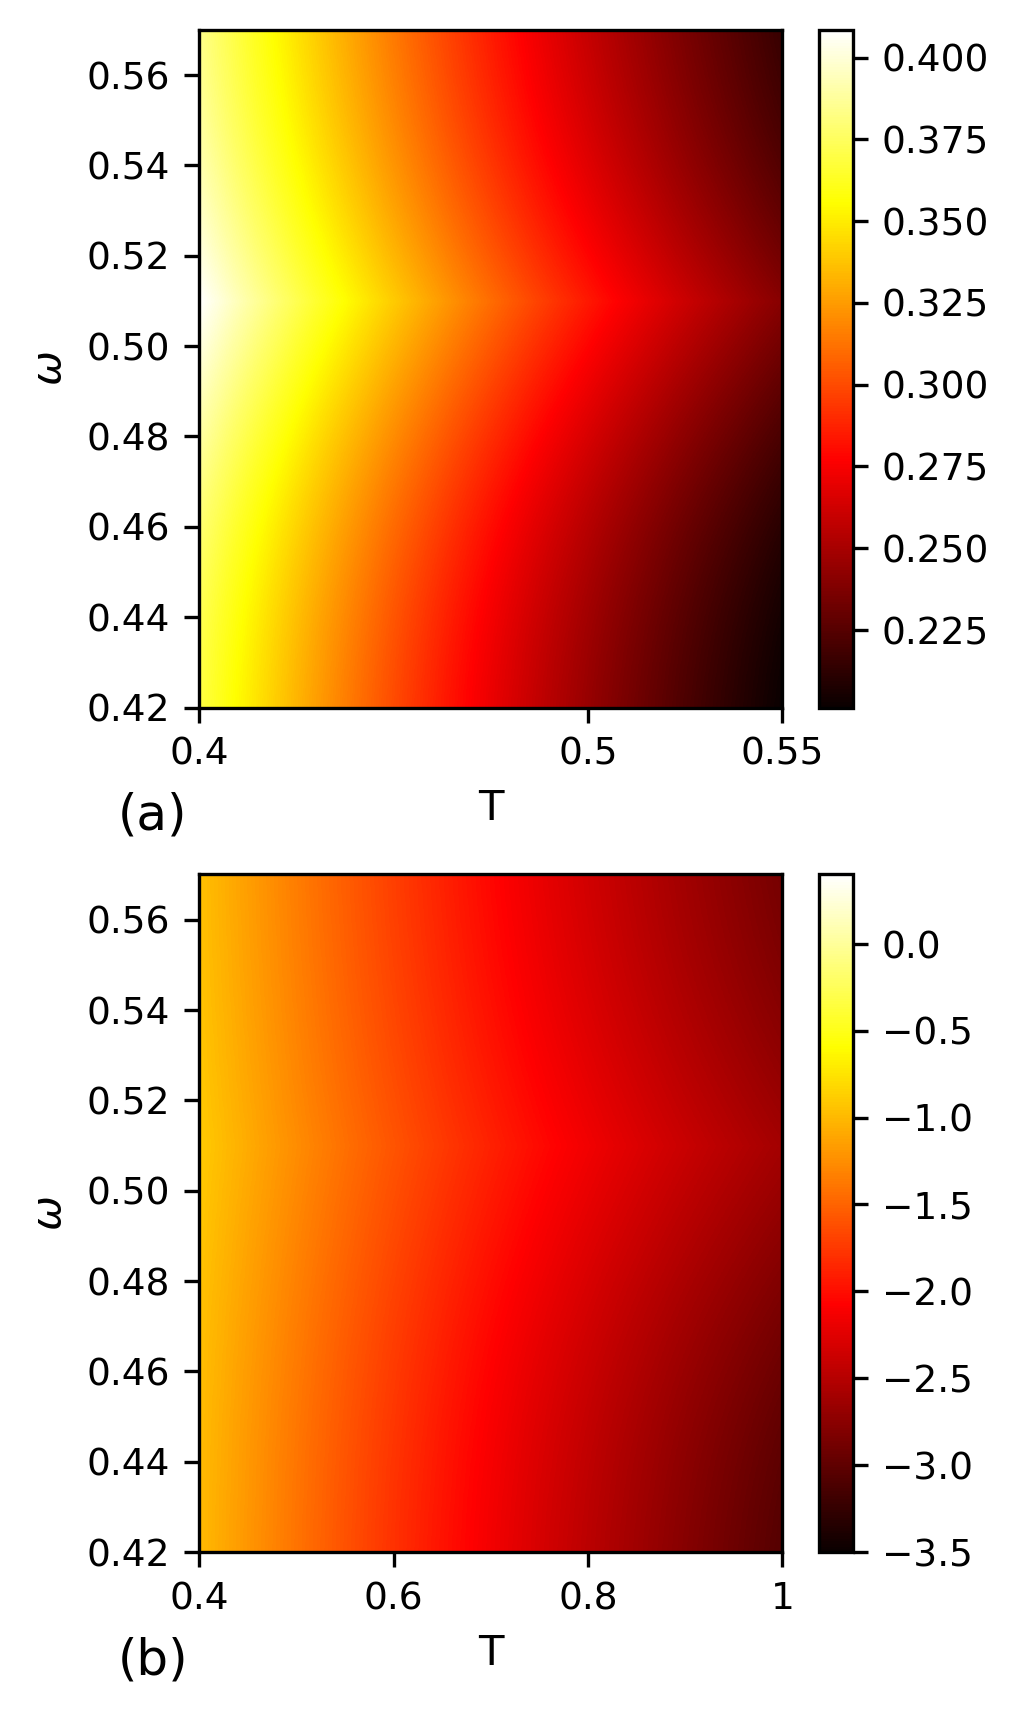

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Tamaños de fuente (documento a 10pt, RevTeX 4-2 -> caption en \small = 9pt)
# ---------------------------------------------------------------------
FONTSIZE   = 10   # etiquetas de ejes (xlabel/ylabel)
TICKSIZE   = 9    # números de los ticks (incluye colorbar)
LABELSIZE  = 12   # etiquetas (a), (b) de cada panel

# Ancho de una columna en RevTeX 4-2 (twocolumn, aps, 10pt) ~ 3.4 in
COLWIDTH = 3.4

d = .1
beta, J = 1, .5
alpha = 0.01


def z_func(x):
    return np.exp(.75 * beta * J / x) + 3 * np.exp(-.25 * beta * J / x)


def lambda1(x):
    return np.exp(.25 * beta * J / x) + np.exp(-.25 * beta * J / x)


def lambda2(x):
    return np.exp(.25 * beta * J / x) - np.exp(-.25 * beta * J / x)


def Ref(x):
    return 2 * J * (J**2 - x**2 + d**2) / (((J + x)**2 + d**2) * ((J - x)**2 + d**2))


fig, axes = plt.subplots(2, 1, figsize=(COLWIDTH, COLWIDTH * 1.7), dpi=300)

# =======================================================================
# Panel (a): LQU (mapa de calor)
# =======================================================================
ax = axes[0]
lquxticks_a = ['0.4', '0.5', '0.55']
x1_a = [.2, .25, .275]
y_a, x_a = np.meshgrid(np.linspace(.42, .57, 1000), np.linspace(.2, .275, 1000))
zval_a = 1 - (2 / z_func(x_a)) * (lambda1(x_a) + 2 * alpha * np.abs(lambda2(x_a) * Ref(y_a)))

c = ax.pcolormesh(x_a, y_a, zval_a, cmap='hot', rasterized=True)
ax.axis([x_a.min(), x_a.max(), y_a.min(), y_a.max()])
cbar = fig.colorbar(c, ax=ax)
cbar.ax.tick_params(labelsize=TICKSIZE)

ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel(r"$\omega$", fontsize=FONTSIZE)
ax.set_xticks(x1_a)
ax.set_xticklabels(lquxticks_a, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.text(-0.14, -0.18, "(a)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
# Panel (b): Log(LQU) (mapa de calor)
# =======================================================================
ax = axes[1]
vmin, vmax = -3.5, .4
loglquxticks_b = ['0.4', '0.6', '0.8', '1']
x2_b = [.2, .3, .4, .5]
y_b, x_b = np.meshgrid(np.linspace(.42, .57, 1000), np.linspace(.2, .5, 1000))
zval_b = np.log(1 - (2 / z_func(x_b)) * (lambda1(x_b) + 2 * alpha * np.abs(lambda2(x_b) * Ref(y_b))))

c = ax.pcolormesh(x_b, y_b, zval_b, cmap='hot', vmin=vmin, vmax=vmax, rasterized=True)
ax.axis([x_b.min(), x_b.max(), y_b.min(), y_b.max()])
cbar = fig.colorbar(c, ax=ax)
cbar.ax.tick_params(labelsize=TICKSIZE)

ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel(r"$\omega$", fontsize=FONTSIZE)
ax.set_xticks(x2_b)
ax.set_xticklabels(loglquxticks_b, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.text(-0.14, -0.18, "(b)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
plt.tight_layout()
plt.savefig('2fig.pdf', dpi=300, bbox_inches='tight')